# 제주 시간별 전력수급 통합표 만들기

공공데이터포털에서 내려받은 **네 종류의 시간별 원자료**를 한 표로 합쳐
`data/processed/제주_시간별_전력수급_통합_2016-2025.xlsx`를 만드는 과정입니다.

| 코드 | 원자료 | 기간 | 단위 | 링크 |
|---|---|---|---|---|
| S03 | 한국전력거래소_제주 일별 시간대별 연계선 수전전력(HVDC) | 2016–2026.6 | MW (2022년 이전 파일은 kW) | https://www.data.go.kr/data/15100403/fileData.do |
| D01 | 한국전력거래소_시간별 제주전력수요 | 2007–2026.6 | MW (일부 파일 kW) | https://www.data.go.kr/data/15065239/fileData.do |
| S01 | 한국전력거래소_제주발전기 연료원 시간대별 전력거래량 | 2010–2025 | MWh | https://www.data.go.kr/data/15161308/fileData.do |
| S07·S14 | 한국전력거래소_시간별 제주 태양광 풍력 제어량 / 전국 태양광 풍력 제어횟수 및 제주 풍력 제어량 | 2015–2024.6 | MWh, 제어 여부 | https://www.data.go.kr/data/15132422/fileData.do |

**만드는 순서**

1. 준비: 라이브러리, 경로, 공통 함수
2. HVDC 연계선: 형식이 다른 파일 16개를 한 형식으로 맞추고 중복 제거 → 보고서 수치와 대조
3. 계통수요: 단위(kW/MW)를 맞추고 중복 제거 → 최대전력 대조
4. 발전원: 연료원 16종을 8개 그룹으로 묶어 시간별 표로 변환
   - 4-2. 출력제어: 풍력 제어량·태양광 제어 시간을 이어 붙이고 보고서와 대조
5. 네 표를 `날짜 + 시` 기준으로 합치고 파생 열(합계·비중) 계산
6. 연도별·월별·시간대 평균 요약과 그래프로 점검
7. CSV·엑셀로 저장

> 이 노트북은 프로젝트 폴더(`제주자치도전력분석/`)에서 실행한다고 가정합니다.
> 한 시간 자료의 값 1 MW는 그 1시간 동안의 전력량 1 MWh와 같으므로, 시간별 값을 더하면 곧바로 MWh가 됩니다.

## 1. 준비

In [1]:
import os, glob, re, io, unicodedata, fnmatch
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.1f}')

# 한글 글꼴: Windows(Malgun Gothic) → 나눔(NanumGothic) → Noto → 굴림 순서로 있는 것 사용
installed = {f.name for f in font_manager.fontManager.ttflist}
prefer = ['Malgun Gothic', 'NanumGothic', 'Noto Sans KR', 'Noto Sans CJK KR', 'Gulim', 'Batang']
fallback = sorted(n for n in installed if 'CJK' in n or 'Nanum' in n or 'Gothic' in n)
font = next((n for n in prefer if n in installed), fallback[0] if fallback else 'Malgun Gothic')
if font:
    plt.rcParams['font.family'] = font
print('그래프 글꼴:', font)
plt.rcParams['axes.unicode_minus'] = False

# 그래프 색: 같은 항목은 모든 그래프에서 같은 색
COLOR = {'HVDC합계': '#2a78d6', '바이오중유': '#eb6834', 'LNG': '#1baf7a', '화력(LNG+유류)': '#1baf7a',
         '태양광': '#eda100', '급전가능재생E(입찰)': '#e87ba4', '재생E(태양광+풍력+입찰)': '#eda100', '풍력': '#b5447a',
         '폐기물': '#4a3aa7', '바이오·소수력 등': '#8a8f96',
         'HVDC#1_해남': '#86b6ef', 'HVDC#2_진도': '#2a78d6', 'HVDC#3_완도': '#104281'}

BASE = Path.cwd()
if not (BASE / 'data' / 'raw').exists():          # 노트북을 data/scripts 등에서 열었을 때 대비
    raw_candidates = [p for p in [BASE, *BASE.parents] if (p / 'data' / 'raw').exists()]
    BASE = raw_candidates[0] if raw_candidates else BASE
RAW = BASE / 'data' / 'raw' if (BASE / 'data' / 'raw').exists() else BASE
OUT = BASE / 'data' / 'processed' if (BASE / 'data' / 'processed').exists() else BASE
OUT.mkdir(exist_ok=True)
print('프로젝트 폴더:', BASE)

그래프 글꼴: Malgun Gothic
프로젝트 폴더: c:\Users\USER\AI-NativeAgent\Project\DS_DB\jeju


### 공통 함수

- **`find()`**: macOS는 한글 파일명을 자모가 분리된 형태(NFD)로 저장하는 경우가 있어서, 코드에 쓴 한글 패턴(NFC)과 글자가 달라 `glob`이 파일을 못 찾을 수 있습니다. 경로를 NFC로 정규화한 뒤 비교합니다.
- **`read_csv_any()`**: 공공데이터포털 CSV는 UTF-8과 CP949(EUC-KR)가 섞여 있습니다. UTF-8로 먼저 읽고 실패하면 CP949로 읽습니다.
- **`to_num()`**: `" 101,960 "`처럼 천 단위 쉼표·공백이 있거나 0을 `-`로 적은 값을 숫자로 바꿉니다.
- **`melt_wide()`**: `날짜, 1시, 2시, … 24시` 형태(가로형)를 `날짜 · 시 · 값` 형태(세로형)로 바꿉니다.

In [2]:
NFC = lambda s: unicodedata.normalize('NFC', str(s))

def find(pattern):
    # RAW 아래에서 pattern(예: '02_HVDC*/**/*.csv')에 맞는 파일을 한글 정규화와 무관하게 찾기
    pat = NFC(pattern)
    hits = [p for p in RAW.rglob('*') if p.is_file() and fnmatch.fnmatch(NFC(p.relative_to(RAW).as_posix()), pat)]
    return sorted(p for p in hits if '_원본' not in NFC(p))    # 백업 폴더(_원본zip, _원본_cp949) 제외

def read_csv_any(path, **kw):
    raw = Path(path).read_bytes()
    for enc in ('utf-8-sig', 'cp949'):
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            continue
    df = pd.read_csv(io.StringIO(text), **kw)
    df.columns = [str(c).strip().replace('﻿', '') for c in df.columns]
    return df

def to_num(s):
    s = s.astype(str).str.strip().str.replace(',', '', regex=False)
    s = s.replace({'-': '0', '': np.nan, 'nan': np.nan})
    return pd.to_numeric(s, errors='coerce')

def melt_wide(df, extra=None):
    date_col = df.columns[0]
    hours = [c for c in df.columns if re.fullmatch(r'\d+시', c)]
    m = df.melt(id_vars=[date_col] + (extra or []), value_vars=hours, var_name='hour', value_name='v')
    m['date'] = pd.to_datetime(m[date_col].astype(str).str.strip(), errors='coerce')
    m['hour'] = m['hour'].str.replace('시', '', regex=False).astype(int)
    m['value'] = to_num(m['v'])
    return m.dropna(subset=['date'])

## 2. HVDC 연계선 (S03)

공공데이터포털은 이 데이터를 분기마다 새 파일로 올렸고, 시기별로 **파일 형식이 세 가지**입니다.

| 형식 | 해당 파일 | 특징 |
|---|---|---|
| ① 세로형 + kW | 2017–2022 통합 파일, 2021년 파일 | `날짜, 구분(HVDC#1…), 1시…24시`, 값이 kW이고 천 단위 쉼표·`-` 포함 |
| ② 세로형 + MW | 2023.1–10 파일 | 형식은 ①과 같고 단위만 MW |
| ③ 가로형 폴더 | 2016년, 2023.11 이후 분기 zip | 연계선마다 파일이 따로 있고 파일명에 `HVDC#1` 표시 |

또한 2025년 2·3분기 파일처럼 **연초부터 누적해 다시 올린 파일**이 있어 같은 시간이 여러 파일에 들어 있습니다.
파일명 앞의 등록 기준일(`S03_HVDC연계선_20250930__…`)이 늦은 파일을 우선하도록 `rank`를 붙인 뒤 중복을 지웁니다.

In [3]:
hv_files = find('02_HVDC*/*.csv') + find('02_HVDC*/*/*.csv')
for p in hv_files:
    print(NFC(p.relative_to(RAW)))

In [4]:
# 형식 ①·②의 예시
sample = read_csv_any(find('02_HVDC*/*2017~2022*.csv')[0], dtype=str)
sample.head(3)

IndexError: list index out of range

In [ ]:
def rank_of(path):
    m = re.search(r'S03_HVDC연계선_(\d{8})', NFC(path))
    return int(m.group(1)) if m else 0

parts = []
for p in hv_files:
    name = NFC(p)
    df = read_csv_any(p, dtype=str)
    if '구분' in df.columns:                                   # 형식 ①·②: 한 파일에 여러 연계선
        unit = 1000.0 if ('2017~2022' in name or '2021년' in name) else 1.0   # kW → MW
        m = melt_wide(df, extra=['구분'])
        m['line'] = '#' + m['구분'].str.extract(r'(\d)')[0]
        m['value'] = m['value'] / unit
    else:                                                      # 형식 ③: 연계선별 파일
        line_no = re.search(r'HVDC#(\d)', name)
        if not line_no:
            continue
        m = melt_wide(df)
        m['line'] = '#' + line_no.group(1)
    m['rank'] = rank_of(p)
    parts.append(m[['date', 'hour', 'line', 'value', 'rank']])

hv_long = pd.concat(parts, ignore_index=True).dropna(subset=['value'])
before = len(hv_long)
hv_long = (hv_long.sort_values('rank')
                  .drop_duplicates(['date', 'hour', 'line'], keep='last')   # 가장 최근 파일 값 사용
                  .sort_values(['date', 'hour', 'line'])
                  .reset_index(drop=True))
print(f'읽은 행 {before:,} → 중복 제거 후 {len(hv_long):,}')

hv = hv_long.pivot_table(index=['date', 'hour'], columns='line', values='value').reset_index()
hv.columns.name = None
hv = hv.rename(columns={'#1': 'HVDC#1_해남', '#2': 'HVDC#2_진도', '#3': 'HVDC#3_완도'})
hv.head()

읽은 행 346,944 → 중복 제거 후 198,600


,date,hour,HVDC#1_해남,HVDC#2_진도,HVDC#3_완도
0,2016-01-01,1,71.2,182.2,NaN
1,2016-01-01,2,70.6,182.2,NaN
2,2016-01-01,3,71.4,182.3,NaN
3,2016-01-01,4,71.2,182.3,NaN
4,2016-01-01,5,72.0,182.2,NaN


연계선별로 연도마다 몇 시간 치 자료가 있는지 확인합니다. 윤년은 8,784시간, #3은 2024년 11월부터 자료가 있습니다.

In [ ]:
HV = ['HVDC#1_해남', 'HVDC#2_진도', 'HVDC#3_완도']
hv.groupby(hv['date'].dt.year)[HV].count()

,HVDC#1_해남,HVDC#2_진도,HVDC#3_완도
date,,,
2016,8784,8784,0
2017,8760,8760,0
2018,8760,8760,0
2019,8760,8760,0
2020,8784,8784,0
2021,8760,8760,0
2022,8760,8760,0
2023,8760,8760,0
2024,8784,8784,1464


### 전력거래소 연간보고서와 대조

전력거래소 「연간 제주지역 전력계통 운영실적」의 HVDC 실적(MWh)과 시간별 합계를 비교합니다.
보고서 HVDC 값은 **수전량 − 역송량(순수전량)**이므로 음수(역송)를 포함해 그대로 더합니다.

In [ ]:
kpx_hvdc = pd.Series({2019: 1_807_934, 2020: 1_689_556, 2021: 1_621_250, 2022: 1_714_314,
                      2023: 1_768_299, 2024: 1_953_740, 2025: 2_062_234}, name='보고서_MWh')
hourly_sum = hv.assign(합계=hv[HV].sum(axis=1)).groupby(hv['date'].dt.year)['합계'].sum().rename('시간별합계_MWh')
chk = pd.concat([hourly_sum, kpx_hvdc], axis=1).dropna()
chk['차이_MWh'] = chk['시간별합계_MWh'] - chk['보고서_MWh']
chk

,시간별합계_MWh,보고서_MWh,차이_MWh
2019,"1,807,933.7","1,807,934.0",-0.3
2020,"1,689,556.4","1,689,556.0",0.4
2021,"1,621,250.0","1,621,250.0",0.0
2022,"1,714,314.2","1,714,314.0",0.2
2023,"1,768,237.8","1,768,299.0",-61.2
2024,"1,937,968.0","1,953,740.0","-15,772.0"
2025,"2,062,233.7","2,062,234.0",-0.3


2024년만 약 15.8 GWh 차이가 납니다. 시간별 파일에 #3 연계선 자료가 2024년 11월부터만 있어 시운전 기간 수전분이 빠진 것으로 보입니다. 나머지 연도는 일치합니다.

## 3. 계통수요 (D01)

이 데이터도 여러 번 나눠 올라왔고, `2017_2023.2`, `20230301-20230930` 두 파일은 **kW 단위**입니다.
파일마다 값의 중앙값이 5,000보다 크면 kW로 보고 1,000으로 나눕니다(제주 수요는 수백~1,000 MW대).

In [ ]:
parts = []
for p in find('03_전력수요*/D01_*.csv'):
    m = melt_wide(read_csv_any(p, dtype=str))
    unit = 1000.0 if m['value'].median() > 5000 else 1.0
    m['value'] = m['value'] / unit
    m['rank'] = int(re.search(r'D01_시간별제주전력수요_(\d{8})', NFC(p)).group(1))
    print(f"{NFC(p.name)[:60]:60s} 단위={'kW' if unit > 1 else 'MW'}  {m['date'].min():%Y-%m-%d}~{m['date'].max():%Y-%m-%d}")
    parts.append(m[['date', 'hour', 'value', 'rank']])

dm = (pd.concat(parts).dropna(subset=['value'])
        .sort_values('rank').drop_duplicates(['date', 'hour'], keep='last')
        .sort_values(['date', 'hour']).reset_index(drop=True)
        .rename(columns={'value': '계통수요_MW'})[['date', 'hour', '계통수요_MW']])
print(f'\n계통수요 {len(dm):,}시간')

D01_시간별제주전력수요_20200731__시간대별 제주 전력수요(2007_2019년).csv         단위=MW  2007-01-01~2019-12-31
D01_시간별제주전력수요_20210831__시간대별 제주 전력수요(2020_2021년 8월).csv      단위=MW  2020-01-01~2021-08-31
D01_시간별제주전력수요_20220804__시간대별 제주 전력수요(2020~2022년 8월).csv      단위=MW  2020-01-01~2022-08-04


D01_시간별제주전력수요_20230228__한국전력거래소_시간별 제주전력수요_2017_2023.2.csv   단위=kW  2017-01-01~2023-02-28
D01_시간별제주전력수요_20230930__한국전력거래소_시간별 제주전력수요_20230301-20230930 단위=kW  2023-03-01~2023-09-30
D01_시간별제주전력수요_20240331__시간별 제주전력수요_240331.csv                단위=MW  2023-09-01~2024-03-31
D01_시간별제주전력수요_20240630__시간별 제주전력수요_240630.csv                단위=MW  2024-04-01~2024-06-30
D01_시간별제주전력수요_20240930__시간별 제주전력수요_241030.csv                단위=MW  2024-07-01~2024-09-30
D01_시간별제주전력수요_20241231__한국전력거래소_시간별 제주전력수요_20241231.csv      단위=MW  2024-10-01~2024-12-31
D01_시간별제주전력수요_20250331__한국전력거래소_시간별 제주전력수요_20250428.csv      단위=MW  2025-01-01~2025-03-31
D01_시간별제주전력수요_20250630__한국전력거래소_시간별 제주전력수요_20250806.csv      단위=MW  2025-01-01~2025-06-30
D01_시간별제주전력수요_20250930__한국전력거래소_시간별 제주전력수요_20251103.csv      단위=MW  2025-01-01~2025-09-30
D01_시간별제주전력수요_20251231__한국전력거래소_시간별 제주전력수요_20260105.csv      단위=MW  2025-10-01~2025-12-31
D01_시간별제주전력수요_20260331__한국전력거래소_시간별 제주전력수요_20260407.csv      단위=MW  2026-01-01~2026-03-31
D01_시간별제주전

In [ ]:
# 최대전력 대조: 전력거래소 보고서 2024년 1,179MW(8/5 14시), 2025년 1,141MW(8/26 18시)
idx = dm.groupby(dm['date'].dt.year)['계통수요_MW'].idxmax()
dm.loc[idx].assign(연=lambda d: d['date'].dt.year).set_index('연').loc[2019:2025]

,date,hour,계통수요_MW
연,,,
2019,2019-08-08,18,965.8
2020,2020-08-14,18,"1,008.6"
2021,2021-08-06,19,"1,012.1"
2022,2022-08-11,20,"1,104.0"
2023,2023-08-03,19,"1,096.4"
2024,2024-08-05,14,"1,178.6"
2025,2025-08-26,18,"1,141.3"


## 4. 제주 발전원별 시간별 거래량 (S01)

연도별 CSV 한 개에 `거래일자(TRAD_YMD) · 시간(TRAD_HH) · 연료원(FUEL_NM) · 전력거래량(AMGO, MWh)`이 세로로 들어 있습니다.
먼저 연료원 종류와 연간 합계를 봅니다.

In [ ]:
s01_files = [p for p in find('01_발전량*/S01_*/*.csv') if int(re.search(r'(\d{4})년도', NFC(p.name)).group(1)) >= 2016]
s01 = pd.concat([read_csv_any(p) for p in s01_files], ignore_index=True)
s01.pivot_table(index='FUEL_NM', columns='TRAD_YY', values='AMGO', aggfunc='sum').fillna(0).round(0)

TRAD_YY,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
FUEL_NM,,,,,,,,,,
DER 발전기,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LNG,0.0,0.0,0.0,"46,246.0","1,389,251.0","1,505,454.0","1,297,172.0","1,391,468.0","1,705,376.0","1,466,306.0"
경유,"1,160.0","2,355.0","100,730.0","603,942.0","63,107.0","113,747.0","239,722.0","259,768.0",0.0,0.0
급전가능 재생에너지,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"355,286.0","888,253.0"
등유,"60,234.0","100,042.0","212,945.0","293,309.0",0.0,0.0,0.0,0.0,0.0,0.0
매립가스,"2,342.0","2,497.0","2,548.0","2,204.0","1,988.0","2,330.0","1,778.0","1,212.0","1,050.0",424.0
바이오가스,"3,093.0","3,549.0","2,897.0","2,146.0","2,161.0","1,977.0","2,718.0","2,291.0",873.0,897.0
바이오매스,"20,579.0","22,528.0","15,942.0","7,349.0","7,485.0","1,484.0","8,538.0","10,546.0","11,782.0","9,216.0"
바이오중유,0.0,0.0,0.0,"1,096,047.0","1,247,271.0","1,284,819.0","1,463,142.0","1,536,136.0","1,366,698.0","1,252,775.0"


읽을 때 볼 점:

- 2019년부터 **중유 → 바이오중유**, 2020년부터 **LNG 복합**이 주력이 됩니다.
- 2024년 6월 **재생에너지 입찰제** 이후 입찰에 참여한 풍력·태양광은 `급전가능 재생에너지`로 따로 잡혀서, `풍력`은 2025년 75.5 GWh로 줄어듭니다. 이 두 열은 합쳐서 봐야 합니다.
- 전력시장에 참여하는 발전기만 있습니다. **PPA 태양광과 자가소비(BTM) 태양광은 없습니다.**

연료원 16종을 8개 그룹으로 묶습니다.

In [ ]:
GROUP = {
    '태양광': '태양광', '풍력': '풍력', '급전가능 재생에너지': '급전가능재생E(입찰)',
    'LNG': 'LNG', '바이오중유': '바이오중유',
    '중유': '중유·경유·등유', '경유': '중유·경유·등유', '등유': '중유·경유·등유',
    '폐기물': '폐기물',
    '바이오매스': '바이오·소수력 등', '바이오가스': '바이오·소수력 등', '매립가스': '바이오·소수력 등',
    '소수력': '바이오·소수력 등', '해양에너지': '바이오·소수력 등', '발전ESS(비중앙)': '바이오·소수력 등', 'DER 발전기': '바이오·소수력 등',
}
GCOLS = ['태양광', '풍력', '급전가능재생E(입찰)', 'LNG', '바이오중유', '중유·경유·등유', '폐기물', '바이오·소수력 등']

s01['grp'] = s01['FUEL_NM'].map(GROUP).fillna('바이오·소수력 등')
gen = (s01.pivot_table(index=['TRAD_YMD', 'TRAD_HH'], columns='grp', values='AMGO', aggfunc='sum')
           .reindex(columns=GCOLS).fillna(0).reset_index()
           .rename(columns={'TRAD_YMD': 'date', 'TRAD_HH': 'hour'}))
gen.columns.name = None
gen['date'] = pd.to_datetime(gen['date'])
print(f'발전원 {len(gen):,}시간')
gen.head()

발전원 87,672시간


,date,hour,태양광,풍력,급전가능재생E(입찰),LNG,바이오중유,중유·경유·등유,폐기물,바이오·소수력 등
0,2016-01-01,1,0.0,40.4,0.0,0.0,0.0,314.7,0.0,3.8
1,2016-01-01,2,0.0,39.3,0.0,0.0,0.0,283.9,0.0,3.9
2,2016-01-01,3,0.0,32.5,0.0,0.0,0.0,265.9,0.0,4.0
3,2016-01-01,4,0.0,30.2,0.0,0.0,0.0,255.9,0.0,4.0
4,2016-01-01,5,0.0,31.8,0.0,0.0,0.0,250.8,0.0,4.0


## 4-2. 출력제어 (S07·S14)

재생에너지가 수요와 연계선 역송 한도를 넘으면 전력거래소가 풍력·태양광 출력을 제한합니다(출력제어).
한 자료에 전 기간이 모여 있지 않아 세 파일을 이어 붙입니다.

| 기간 | 파일 | 내용 | 주의 |
|---|---|---|---|
| 2015–2016 | S07 `제주 풍력 및 태양광 제어량.csv` (2022.11 등록) | 풍력 시간별 제어량 | `일자`가 `825`(8/25), `111`(11/1)처럼 월·일이 붙어 있어 회차 순서로 날짜를 정함 |
| 2017–2020 | S07 `월별 시간별 … 제어량 및 제어 횟수` (2023.3 등록) | 풍력 시간별 제어량 | |
| 2021–2024.6 | S14 `제주 풍력 출력제어횟수 및 제어량.csv`, `제주 태양광 출력제어횟수.csv` (2026.6 등록 최신본) | 풍력 제어량, 태양광 제어 시각 | 태양광은 제어량을 산정하지 않고 `출력제어` 표시만 있음 |

- 링크: https://www.data.go.kr/data/15108268/fileData.do , https://www.data.go.kr/data/15132422/fileData.do
- 2024년 6월 재생에너지 입찰제 도입 후 제주 출력제어 실적은 없습니다(최신 파일 설명). 그래서 이후 기간은 0으로 두고 `출력제어_자료구분` 열로 구분합니다.
- 풍력 제어량은 “차단 시점 발전량을 차단 시간으로 환산한 값”이라 참고치입니다.

In [ ]:
HOURS = [f'{i}시' for i in range(1, 25)]

def ct_file(folder_pat, name_pat):
    for p in find('05_발전설비*/*.csv') + find('05_발전설비*/*/*.csv'):
        if re.search(folder_pat, NFC(p)) and re.search(name_pat, NFC(p.name)):
            return p
    raise FileNotFoundError(name_pat)

def to_hourly(d, date_col):
    m = d.melt(id_vars=[date_col], value_vars=HOURS, var_name='hour', value_name='v')
    m['date'] = pd.to_datetime(m[date_col])
    m['hour'] = m['hour'].str.replace('시', '').astype(int)
    return m

# (1) 풍력 2015-2016: '111'은 1/11일 수도 11/1일 수도 있음 → 같은 해 앞 회차보다 늦은 날짜를 선택
o = read_csv_any(ct_file(r'S07_태양광풍력제어량_20221118', r'제어량\.csv$'))
o = o[(o['구분'] == '풍력') & (o['연도'] <= 2016)].sort_values(['연도', '연도별 시행회차'])
dates, prev = [], None
for _, r in o.iterrows():
    t, y = str(int(r['일자'])), int(r['연도'])
    cands = sorted({pd.Timestamp(y, int(t[:k]), int(t[k:])) for k in (1, 2)
                    if 0 < k < len(t) and 1 <= int(t[:k]) <= 12 and 1 <= int(t[k:]) <= 31})
    cands = [c for c in cands if prev is None or c > prev or c.year != prev.year]
    prev = cands[0]
    dates.append(prev)
o['기준일'] = dates
print(o[['연도', '일자', '연도별 시행회차', '기준일']].to_string(index=False))

  연도   일자  연도별 시행회차        기준일
2015  825         1 2015-08-25
2015  102         2 2015-10-02
2015 1011         3 2015-10-11
2016  417         1 2016-04-17
2016  516         2 2016-05-16
2016 1029         3 2016-10-29
2016  111         4 2016-11-01
2016  118         5 2016-11-08
2016 1115         6 2016-11-15


In [ ]:
# (2) 풍력 2017-2020, (3) 풍력 2021-2024.6
a = read_csv_any(ct_file(r'S07_태양광풍력제어량_20230319', r'제어량'))
a = a[(a['구분'] == '풍력') & (a['기준일'] < '2021-01-01')]
b = read_csv_any(ct_file(r'S14_.*_20260630', r'^제주 풍력'))

wind = pd.concat([to_hourly(o[['기준일'] + HOURS], '기준일'),
                  to_hourly(a[['기준일'] + HOURS], '기준일'),
                  to_hourly(b[['일자'] + HOURS], '일자')])
wind['v'] = pd.to_numeric(wind['v'], errors='coerce').fillna(0)
wind = wind.groupby(['date', 'hour'])['v'].sum().rename('풍력_출력제어량_MWh').reset_index()

# (4) 태양광: '출력제어' 표시가 있는 시간 = 1
sfile = read_csv_any(ct_file(r'S14_.*_20260630', r'^제주 태양광'))
sol = to_hourly(sfile[['일자'] + HOURS], '일자')
sol['태양광_출력제어'] = (sol['v'].astype(str).str.strip() == '출력제어').astype(int)
sol = sol.groupby(['date', 'hour'])['태양광_출력제어'].max().reset_index()

ct = wind.merge(sol, on=['date', 'hour'], how='outer')
print(f'풍력 제어 기록 {(ct["풍력_출력제어량_MWh"] > 0).sum():,}시간, 태양광 제어 {int(ct["태양광_출력제어"].sum()):,}시간')

풍력 제어 기록 2,360시간, 태양광 제어 521시간


전력거래소 연간보고서의 출력제어 실적과 대조합니다(2023년 풍력 117회·26,201 MWh, 태양광 64회 / 2024년 풍력 51회·9,370 MWh, 태양광 32회).

In [ ]:
chk_ct = pd.DataFrame({
    '풍력_제어량_MWh': ct.groupby(ct['date'].dt.year)['풍력_출력제어량_MWh'].sum(),
    '풍력_제어일수': ct[ct['풍력_출력제어량_MWh'] > 0].groupby(ct['date'].dt.year)['date'].nunique(),
    '태양광_제어일수': ct[ct['태양광_출력제어'] == 1].groupby(ct['date'].dt.year)['date'].nunique(),
}).fillna(0)
chk_ct['보고서_풍력_MWh'] = pd.Series({2023: 26_201, 2024: 9_370})
chk_ct

,풍력_제어량_MWh,풍력_제어일수,태양광_제어일수,보고서_풍력_MWh
date,,,,
2015,151.6,3,0.0,NaN
2016,252.1,6,0.0,NaN
2017,"1,300.7",14,0.0,NaN
2018,"1,365.9",15,0.0,NaN
2019,"9,224.5",46,0.0,NaN
2020,"19,452.1",77,0.0,NaN
2021,"12,016.0",63,1.0,NaN
2022,"25,638.0",104,28.0,NaN
2023,"26,197.0",117,64.0,"26,201.0"


## 5. 세 표 합치기와 파생 열

`날짜 + 시(1~24)`를 열쇠로 계통수요 표에 HVDC와 발전원을 붙입니다. 세 자료가 모두 있는 **2016-01-01 ~ 2025-12-31**만 남깁니다.

| 파생 열 | 계산 |
|---|---|
| HVDC합계 | #1 + #2 + #3 (음수는 제주 → 육지 역송) |
| 재생E(태양광+풍력+입찰) | 태양광 + 풍력 + 급전가능재생E |
| 화력(LNG+유류) | LNG + 바이오중유 + 중유·경유·등유 |
| 제주발전합계 | 발전원 8개 그룹 합 |
| 공급합계(발전+HVDC) | 제주발전합계 + HVDC합계 |
| 시장밖·차이(수요-공급) | 계통수요 − 공급합계. 주로 PPA 태양광 등 시장 밖 발전분 |
| HVDC비중_%, 재생E비중_% | 계통수요 대비 비율 |
| 풍력_출력제어량_MWh, 풍력_출력제어, 태양광_출력제어 | 4-2의 출력제어 자료(제어 시간 = 1) |

In [ ]:
df = (dm.merge(hv, on=['date', 'hour'], how='left')
        .merge(gen, on=['date', 'hour'], how='left')
        .merge(ct, on=['date', 'hour'], how='left'))
df = df[(df['date'] >= '2016-01-01') & (df['date'] <= '2025-12-31')].sort_values(['date', 'hour']).reset_index(drop=True)

df['HVDC합계'] = df[HV].sum(axis=1, min_count=1)
df['재생E(태양광+풍력+입찰)'] = df['태양광'] + df['풍력'] + df['급전가능재생E(입찰)']
df['화력(LNG+유류)'] = df['LNG'] + df['바이오중유'] + df['중유·경유·등유']
df['제주발전합계'] = df[GCOLS].sum(axis=1)
df['공급합계(발전+HVDC)'] = df['제주발전합계'] + df['HVDC합계']
df['시장밖·차이(수요-공급)'] = df['계통수요_MW'] - df['공급합계(발전+HVDC)']
df['HVDC비중_%'] = df['HVDC합계'] / df['계통수요_MW'] * 100
df['재생E비중_%'] = df['재생E(태양광+풍력+입찰)'] / df['계통수요_MW'] * 100

# 출력제어: 기록 없는 시간은 0, 2024년 6월 이후는 입찰제로 출력제어 실적 없음
df['풍력_출력제어량_MWh'] = df['풍력_출력제어량_MWh'].fillna(0).round(3)
df['풍력_출력제어'] = (df['풍력_출력제어량_MWh'] > 0).astype(int)
df['태양광_출력제어'] = df['태양광_출력제어'].fillna(0).astype(int)
df['출력제어_자료구분'] = np.where(df['date'] < '2024-06-01', '실적(전력거래소)', '입찰제 이후 출력제어 실적 없음')
CTC = ['풍력_출력제어량_MWh', '풍력_출력제어', '태양광_출력제어', '출력제어_자료구분']
df = df[[c for c in df.columns if c not in CTC] + CTC]

# '시'는 그 시각에 끝나는 1시간(1시 = 00:00~01:00). 일시 열은 구간의 시작 시각
df.insert(0, '일시', df['date'] + pd.to_timedelta(df['hour'] - 1, unit='h'))
df.insert(1, '연', df['date'].dt.year)
df.insert(2, '월', df['date'].dt.month)
df = df.rename(columns={'date': '날짜', 'hour': '시(1~24)'})

VAL = (['계통수요_MW'] + HV + ['HVDC합계'] + GCOLS +
       ['재생E(태양광+풍력+입찰)', '화력(LNG+유류)', '제주발전합계', '공급합계(발전+HVDC)', '시장밖·차이(수요-공급)'])
df[VAL] = df[VAL].round(3)
df[['HVDC비중_%', '재생E비중_%']] = df[['HVDC비중_%', '재생E비중_%']].round(2)

print(f'{len(df):,}시간 × {df.shape[1]}열, 빈 값이 있는 열:')
print(df[VAL].isna().sum()[lambda s: s > 0])
df.head()

87,672시간 × 29열, 빈 값이 있는 열:
HVDC#3_완도    77448
dtype: int64


,일시,연,월,날짜,시(1~24),계통수요_MW,HVDC#1_해남,HVDC#2_진도,HVDC#3_완도,태양광,풍력,급전가능재생E(입찰),LNG,바이오중유,중유·경유·등유,폐기물,바이오·소수력 등,HVDC합계,재생E(태양광+풍력+입찰),화력(LNG+유류),제주발전합계,공급합계(발전+HVDC),시장밖·차이(수요-공급),HVDC비중_%,재생E비중_%,풍력_출력제어량_MWh,풍력_출력제어,태양광_출력제어,출력제어_자료구분
0,2016-01-01 00:00:00,2016,1,2016-01-01,1,633.0,71.2,182.2,NaN,0.0,40.4,0.0,0.0,0.0,314.7,0.0,3.8,253.4,40.4,314.7,358.8,612.2,20.9,40.0,6.4,0.0,0,0,실적(전력거래소)
1,2016-01-01 01:00:00,2016,1,2016-01-01,2,600.5,70.6,182.2,NaN,0.0,39.3,0.0,0.0,0.0,283.9,0.0,3.9,252.8,39.3,283.9,327.1,579.8,20.6,42.1,6.5,0.0,0,0,실적(전력거래소)
2,2016-01-01 02:00:00,2016,1,2016-01-01,3,576.4,71.4,182.3,NaN,0.0,32.5,0.0,0.0,0.0,265.9,0.0,4.0,253.7,32.5,265.9,302.5,556.1,20.2,44.0,5.6,0.0,0,0,실적(전력거래소)
3,2016-01-01 03:00:00,2016,1,2016-01-01,4,563.1,71.2,182.3,NaN,0.0,30.2,0.0,0.0,0.0,255.9,0.0,4.0,253.5,30.2,255.9,290.1,543.6,19.5,45.0,5.4,0.0,0,0,실적(전력거래소)
4,2016-01-01 04:00:00,2016,1,2016-01-01,5,560.7,72.0,182.2,NaN,0.0,31.8,0.0,0.0,0.0,250.8,0.0,4.0,254.3,31.8,250.8,286.6,540.9,19.8,45.4,5.7,0.0,0,0,실적(전력거래소)


HVDC #3는 2024년 11월 전에 없었으므로 빈 값이 정상입니다. 나머지 열에는 빈 값이 없어야 합니다.

## 6. 요약과 점검

In [ ]:
yr = (df.groupby('연')[VAL].sum() / 1000).round(1)                     # MWh 합 → GWh
for c in HV + ['HVDC합계']:
    yr[c.replace('HVDC', '역송') + '_GWh'] = (-df[c].clip(upper=0)).groupby(df['연']).sum().div(1000).round(1)
yr['HVDC비중_%'] = (yr['HVDC합계'] / yr['계통수요_MW'] * 100).round(1)
yr['재생E비중_%'] = (yr['재생E(태양광+풍력+입찰)'] / yr['계통수요_MW'] * 100).round(1)
yr['HVDC비중_최대시간_%'] = df.groupby('연')['HVDC비중_%'].max().round(1)
yr['재생E비중_최대시간_%'] = df.groupby('연')['재생E비중_%'].max().round(1)
yr['역송발생시간_h'] = (df['HVDC합계'] < 0).groupby(df['연']).sum()
yr['풍력_출력제어량_MWh'] = df.groupby('연')['풍력_출력제어량_MWh'].sum().round(1)
yr['풍력_출력제어_일수'] = df[df['풍력_출력제어'] == 1].groupby('연')['날짜'].nunique().reindex(yr.index, fill_value=0)
yr['풍력_출력제어_시간'] = df.groupby('연')['풍력_출력제어'].sum()
yr['태양광_출력제어_일수'] = df[df['태양광_출력제어'] == 1].groupby('연')['날짜'].nunique().reindex(yr.index, fill_value=0)
yr['태양광_출력제어_시간'] = df.groupby('연')['태양광_출력제어'].sum()
yr['자료시간수'] = df.groupby('연').size()
yr = yr.rename(columns=lambda c: c[:-3] if c.endswith('_MW') else c)

mo = (df.groupby(['연', '월'])[VAL].sum() / 1000).round(1).rename(columns=lambda c: c[:-3] if c.endswith('_MW') else c)
mo['풍력_출력제어량_MWh'] = df.groupby(['연', '월'])['풍력_출력제어량_MWh'].sum().round(1)
mo['태양광_출력제어_시간'] = df.groupby(['연', '월'])['태양광_출력제어'].sum()
prof = df.groupby(['연', '시(1~24)'])[VAL].mean().round(1)

yr[['계통수요', 'HVDC합계', '제주발전합계', '재생E(태양광+풍력+입찰)', '시장밖·차이(수요-공급)',
    'HVDC비중_%', '재생E비중_%', '역송발생시간_h', '풍력_출력제어량_MWh', '태양광_출력제어_일수', '자료시간수']]

,계통수요,HVDC합계,제주발전합계,재생E(태양광+풍력+입찰),시장밖·차이(수요-공급),HVDC비중_%,재생E비중_%,역송발생시간_h,풍력_출력제어량_MWh,태양광_출력제어_일수,자료시간수
연,,,,,,,,,,,
2016,"5,127.5","2,002.6","2,931.5",550.0,193.5,39.1,10.7,0,252.0,0,8784
2017,"5,422.0","2,297.3","2,939.6",672.6,185.2,42.4,12.4,0,"1,300.7",0,8760
2018,"5,675.6","2,272.0","3,210.9",699.8,192.7,40.0,12.3,0,"1,365.9",0,8760
2019,"5,719.0","1,807.9","3,720.2",811.0,190.9,31.6,14.2,0,"9,224.5",0,8760
2020,"5,677.8","1,689.6","3,824.3",910.1,163.9,29.8,16.0,0,"19,452.1",0,8784
2021,"5,871.1","1,621.3","4,070.2",879.9,179.7,27.6,15.0,24,"12,016.0",1,8760
2022,"6,213.0","1,714.3","4,317.9",975.8,180.7,27.6,15.7,5,"25,638.0",28,8760
2023,"6,321.2","1,768.2","4,359.7","1,001.0",193.3,28.0,15.8,153,"26,197.0",64,8760
2024,"6,460.9","1,938.0","4,340.9","1,173.8",182.0,30.0,18.2,117,"9,373.0",32,8784


`시장밖·차이`가 해마다 수요의 약 2~4%(140~195 GWh)로 일정하면 세 자료가 제대로 맞춰진 것입니다. 한 해만 크게 튀면 단위 변환이나 중복 제거를 다시 확인합니다.

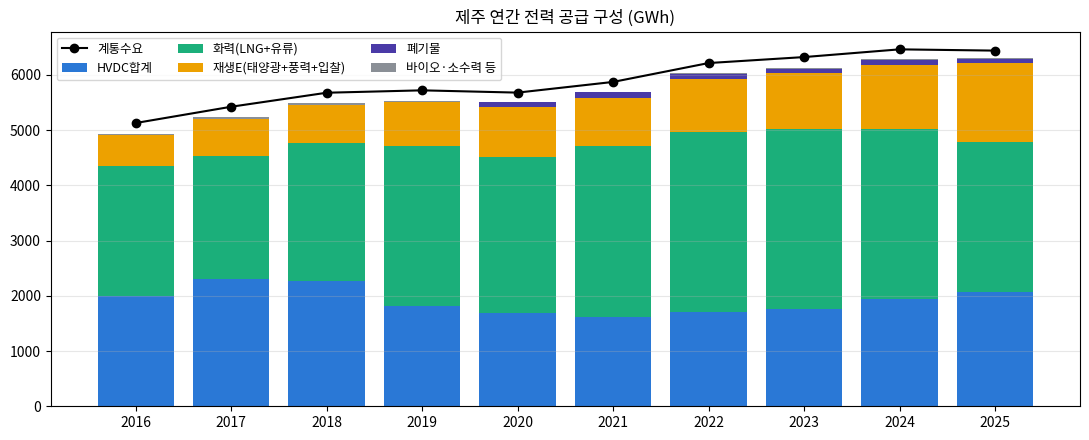

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
parts = ['HVDC합계', '화력(LNG+유류)', '재생E(태양광+풍력+입찰)', '폐기물', '바이오·소수력 등']
bottom = np.zeros(len(yr))
for c in parts:
    ax.bar(yr.index, yr[c], bottom=bottom, label=c, color=COLOR[c])
    bottom += yr[c].values
ax.plot(yr.index, yr['계통수요'], color='black', marker='o', label='계통수요')
ax.set_title('제주 연간 전력 공급 구성 (GWh)')
ax.set_xticks(yr.index)
ax.legend(ncol=3, fontsize=9, loc='upper left')
ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

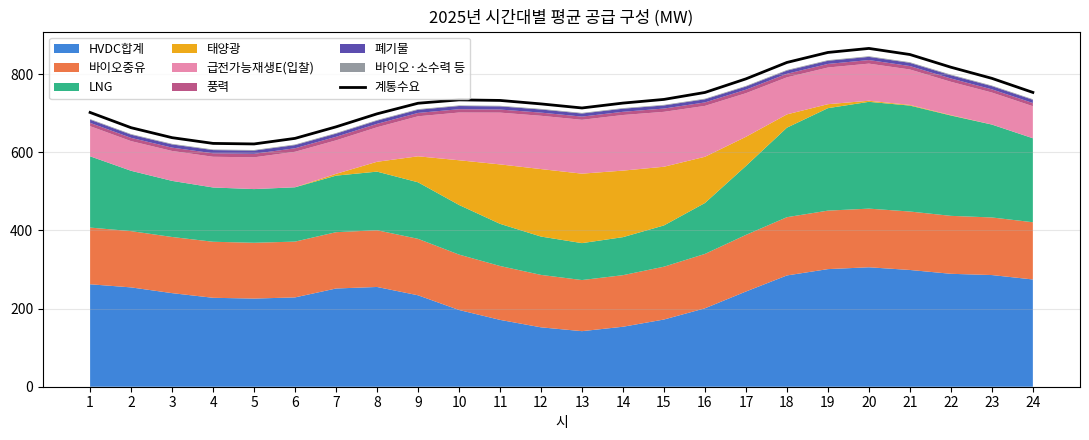

In [ ]:
# 2025년 하루 중 흐름(시간대 평균): 낮에는 태양광이 늘고 HVDC 수전이 줄어듦
p25 = prof.loc[2025]
fig, ax = plt.subplots(figsize=(11, 4.5))
stack = ['HVDC합계', '바이오중유', 'LNG', '태양광', '급전가능재생E(입찰)', '풍력', '폐기물', '바이오·소수력 등']
ax.stackplot(p25.index, [p25[c] for c in stack], labels=stack, colors=[COLOR[c] for c in stack], alpha=.9)
ax.plot(p25.index, p25['계통수요_MW'], color='black', lw=2, label='계통수요')
ax.set_title('2025년 시간대별 평균 공급 구성 (MW)')
ax.set_xticks(range(1, 25)); ax.set_xlabel('시')
ax.legend(ncol=3, fontsize=9, loc='upper left'); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

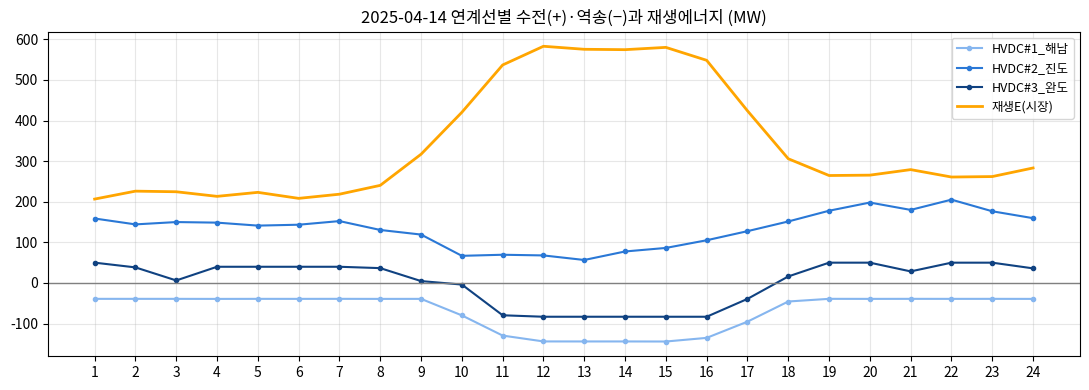

In [ ]:
# 2025년 중 HVDC 합계가 가장 많이 역송된 날의 24시간
day = df.loc[df.loc[df['연'] == 2025, 'HVDC합계'].idxmin(), '날짜']
d1 = df[df['날짜'] == day].set_index('시(1~24)')
fig, ax = plt.subplots(figsize=(11, 4))
for c in HV:
    ax.plot(d1.index, d1[c], marker='o', ms=3, label=c, color=COLOR[c])
ax.plot(d1.index, d1['재생E(태양광+풍력+입찰)'], color='orange', lw=2, label='재생E(시장)')
ax.axhline(0, color='gray', lw=1)
ax.set_title(f'{day:%Y-%m-%d} 연계선별 수전(+)·역송(−)과 재생에너지 (MW)')
ax.set_xticks(range(1, 25)); ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. 저장

- `제주_시간별_전력수급_통합_2016-2025.csv`: 시간별 전체 (UTF-8 BOM이라 Excel·Numbers에서 한글이 깨지지 않음)
- `제주_시간별_전력수급_통합_2016-2025.xlsx`: 설명 · 연도별 · 월별 · 시간대평균 · 시간별 시트

In [ ]:
df.to_csv(OUT / '제주_시간별_전력수급_통합_2016-2025.csv', index=False, encoding='utf-8-sig')

notes = pd.DataFrame({'항목': ['단위', '시각', 'HVDC', '발전원', '급전가능재생E(입찰)', '시장밖·차이', '기간', '출처', '만든 곳', '출력제어'],
    '설명': [
        '시간별 시트는 MW(=해당 1시간의 MWh), 연도별·월별 시트는 GWh, 시간대평균은 MW',
        '"시(1~24)"는 해당 시각에 끝나는 1시간(예: 1시 = 00:00~01:00). CSV의 일시 열은 구간 시작 시각',
        '연계선별 순수전력. 음수는 제주→육지 역송. #3 완도 연계선은 2024년 11월부터 자료 있음',
        '전력거래소 시장 참여 발전기의 전력거래량(송전단). PPA 태양광·자가용(BTM)은 포함되지 않음',
        '2024년 6월 재생에너지 입찰제 이후 입찰에 참여한 풍력·태양광(대부분 풍력). 이후 "풍력" 열은 비입찰분만 남아 작아짐',
        '계통수요 − (제주 시장 발전 + HVDC). 주로 PPA 태양광 등 시장 밖 발전분과 기준 차이',
        f'{df["일시"].min():%Y-%m-%d %H시} 시작 ~ {df["날짜"].max():%Y-%m-%d} 24시 ({len(df):,}시간)',
        '공공데이터포털: 연계선 수전전력(HVDC) 15100403, 제주발전기 연료원 시간대별 전력거래량 15161308, 시간별 제주전력수요 15065239',
        '제주_시간별_전력수급_통합_만들기.ipynb',
        '풍력_출력제어량_MWh: 차단 시점 발전량을 차단 시간으로 환산한 참고치. 태양광_출력제어: 제어 시행 시간 1/0(제어량 미산정, 2021.10 첫 시행). 2024.6 재생에너지 입찰제 이후 제주 출력제어 실적 없음(0). 출처: 공공데이터포털 15108268, 15132422']})

xlsx = OUT / '제주_시간별_전력수급_통합_2016-2025.xlsx'
with pd.ExcelWriter(xlsx, engine='xlsxwriter') as w:        # xlsxwriter가 없으면 engine='openpyxl'
    notes.to_excel(w, sheet_name='설명', index=False)
    yr.reset_index().to_excel(w, sheet_name='연도별_GWh', index=False)
    mo.reset_index().to_excel(w, sheet_name='월별_GWh', index=False)
    prof.reset_index().to_excel(w, sheet_name='시간대평균_MW', index=False)
    df.drop(columns=['일시']).assign(날짜=df['날짜'].dt.date).to_excel(w, sheet_name='시간별_MW', index=False)
    for name, sh in w.sheets.items():
        sh.freeze_panes(1, 0 if name == '설명' else 2)
        sh.set_column(0, 40, 13)
    w.sheets['설명'].set_column(0, 0, 20)
    w.sheets['설명'].set_column(1, 1, 110)
print('저장:', xlsx, f'{xlsx.stat().st_size / 1e6:.1f} MB')

저장: /sessions/rcw-017zm47vqedgwpyqrt8otjlj/mnt/제주자치도전력분석/data/processed/제주_시간별_전력수급_통합_2016-2025.xlsx 12.9 MB


In [ ]:
# 저장한 파일을 다시 읽어 확인
check = pd.read_excel(xlsx, sheet_name='연도별_GWh')
check[['연', '계통수요', 'HVDC합계', '제주발전합계', 'HVDC비중_%', '재생E비중_%']]

,연,계통수요,HVDC합계,제주발전합계,HVDC비중_%,재생E비중_%
0,2016,"5,127.5","2,002.6","2,931.5",39.1,10.7
1,2017,"5,422.0","2,297.3","2,939.6",42.4,12.4
2,2018,"5,675.6","2,272.0","3,210.9",40.0,12.3
3,2019,"5,719.0","1,807.9","3,720.2",31.6,14.2
4,2020,"5,677.8","1,689.6","3,824.3",29.8,16.0
5,2021,"5,871.1","1,621.3","4,070.2",27.6,15.0
6,2022,"6,213.0","1,714.3","4,317.9",27.6,15.7
7,2023,"6,321.2","1,768.2","4,359.7",28.0,15.8
8,2024,"6,460.9","1,938.0","4,340.9",30.0,18.2
9,2025,"6,438.1","2,062.2","4,233.4",32.0,22.2


## 참고: 이 표로 할 수 있는 분석 예

- 시간별 `HVDC비중_%`가 가장 높은 시간과 계절 → 육지 의존이 커지는 때
- `HVDC#1_해남`이 음수인 시간의 분포 → 봄·가을 낮 역송 패턴
- 연도별 `시간대평균_MW` 시트로 태양광 증가에 따른 낮 시간 수요곡선(덕커브) 변화 비교
- 여름·겨울 최대전력 시각의 공급 구성 비교

## 8. 10년간(2016~2025) 시간대별 발전 종류별 공급 구성 변화

`제주_시간별_전력수급_통합_2016-2025.xlsx` 파일의 `시간대평균_MW` 시트를 사용하여,
가로축은 시간(t: 1~24시), 세로는 각 에너지별 발전량(MW)으로 첨부된 이미지와 동일한 형태의 누적 영역 그래프(Stackplot)와 계통수요 선 그래프(Line plot)를 구성합니다.

- **발전 종류 (첨부 이미지 기준 9개 항목)**:
  1. `HVDC합계` (파랑, `#2a78d6`)
  2. `바이오중유` (주황, `#eb6834`)
  3. `LNG` (청록, `#1baf7a`)
  4. `태양광` (황금색, `#eda100`)
  5. `급전가능재생E(입찰)` (분홍, `#e87ba4`)
  6. `풍력` (자주, `#b5447a`)
  7. `폐기물` (보라, `#4a3aa7`)
  8. `바이오·소수력 등` (회색, `#8a8f96`)
  9. `계통수요` (검정 실선, `black`, lw=2)

> **참고 (연도별 유류 전환 배경)**:
> 2016~2018년 제주는 바이오중유 도입 전 기존 화석 유류('중유·경유·등유')를 주 연료로 사용했습니다. 
> 2019~2020년부터 바이오중유와 LNG로 본격 전환되었으므로, 이미지 기준 9개 항목을 그대로 적용하면 2016~2019년은 당시 기존 유류 발전량만큼 차이가 표시됩니다. 
> 아래 코드에서는 이미지 기준 9개 항목을 기본으로 그리며, 유류 전체를 포함해 볼 수 있는 옵션(`include_legacy_oil`)도 함께 제공합니다.

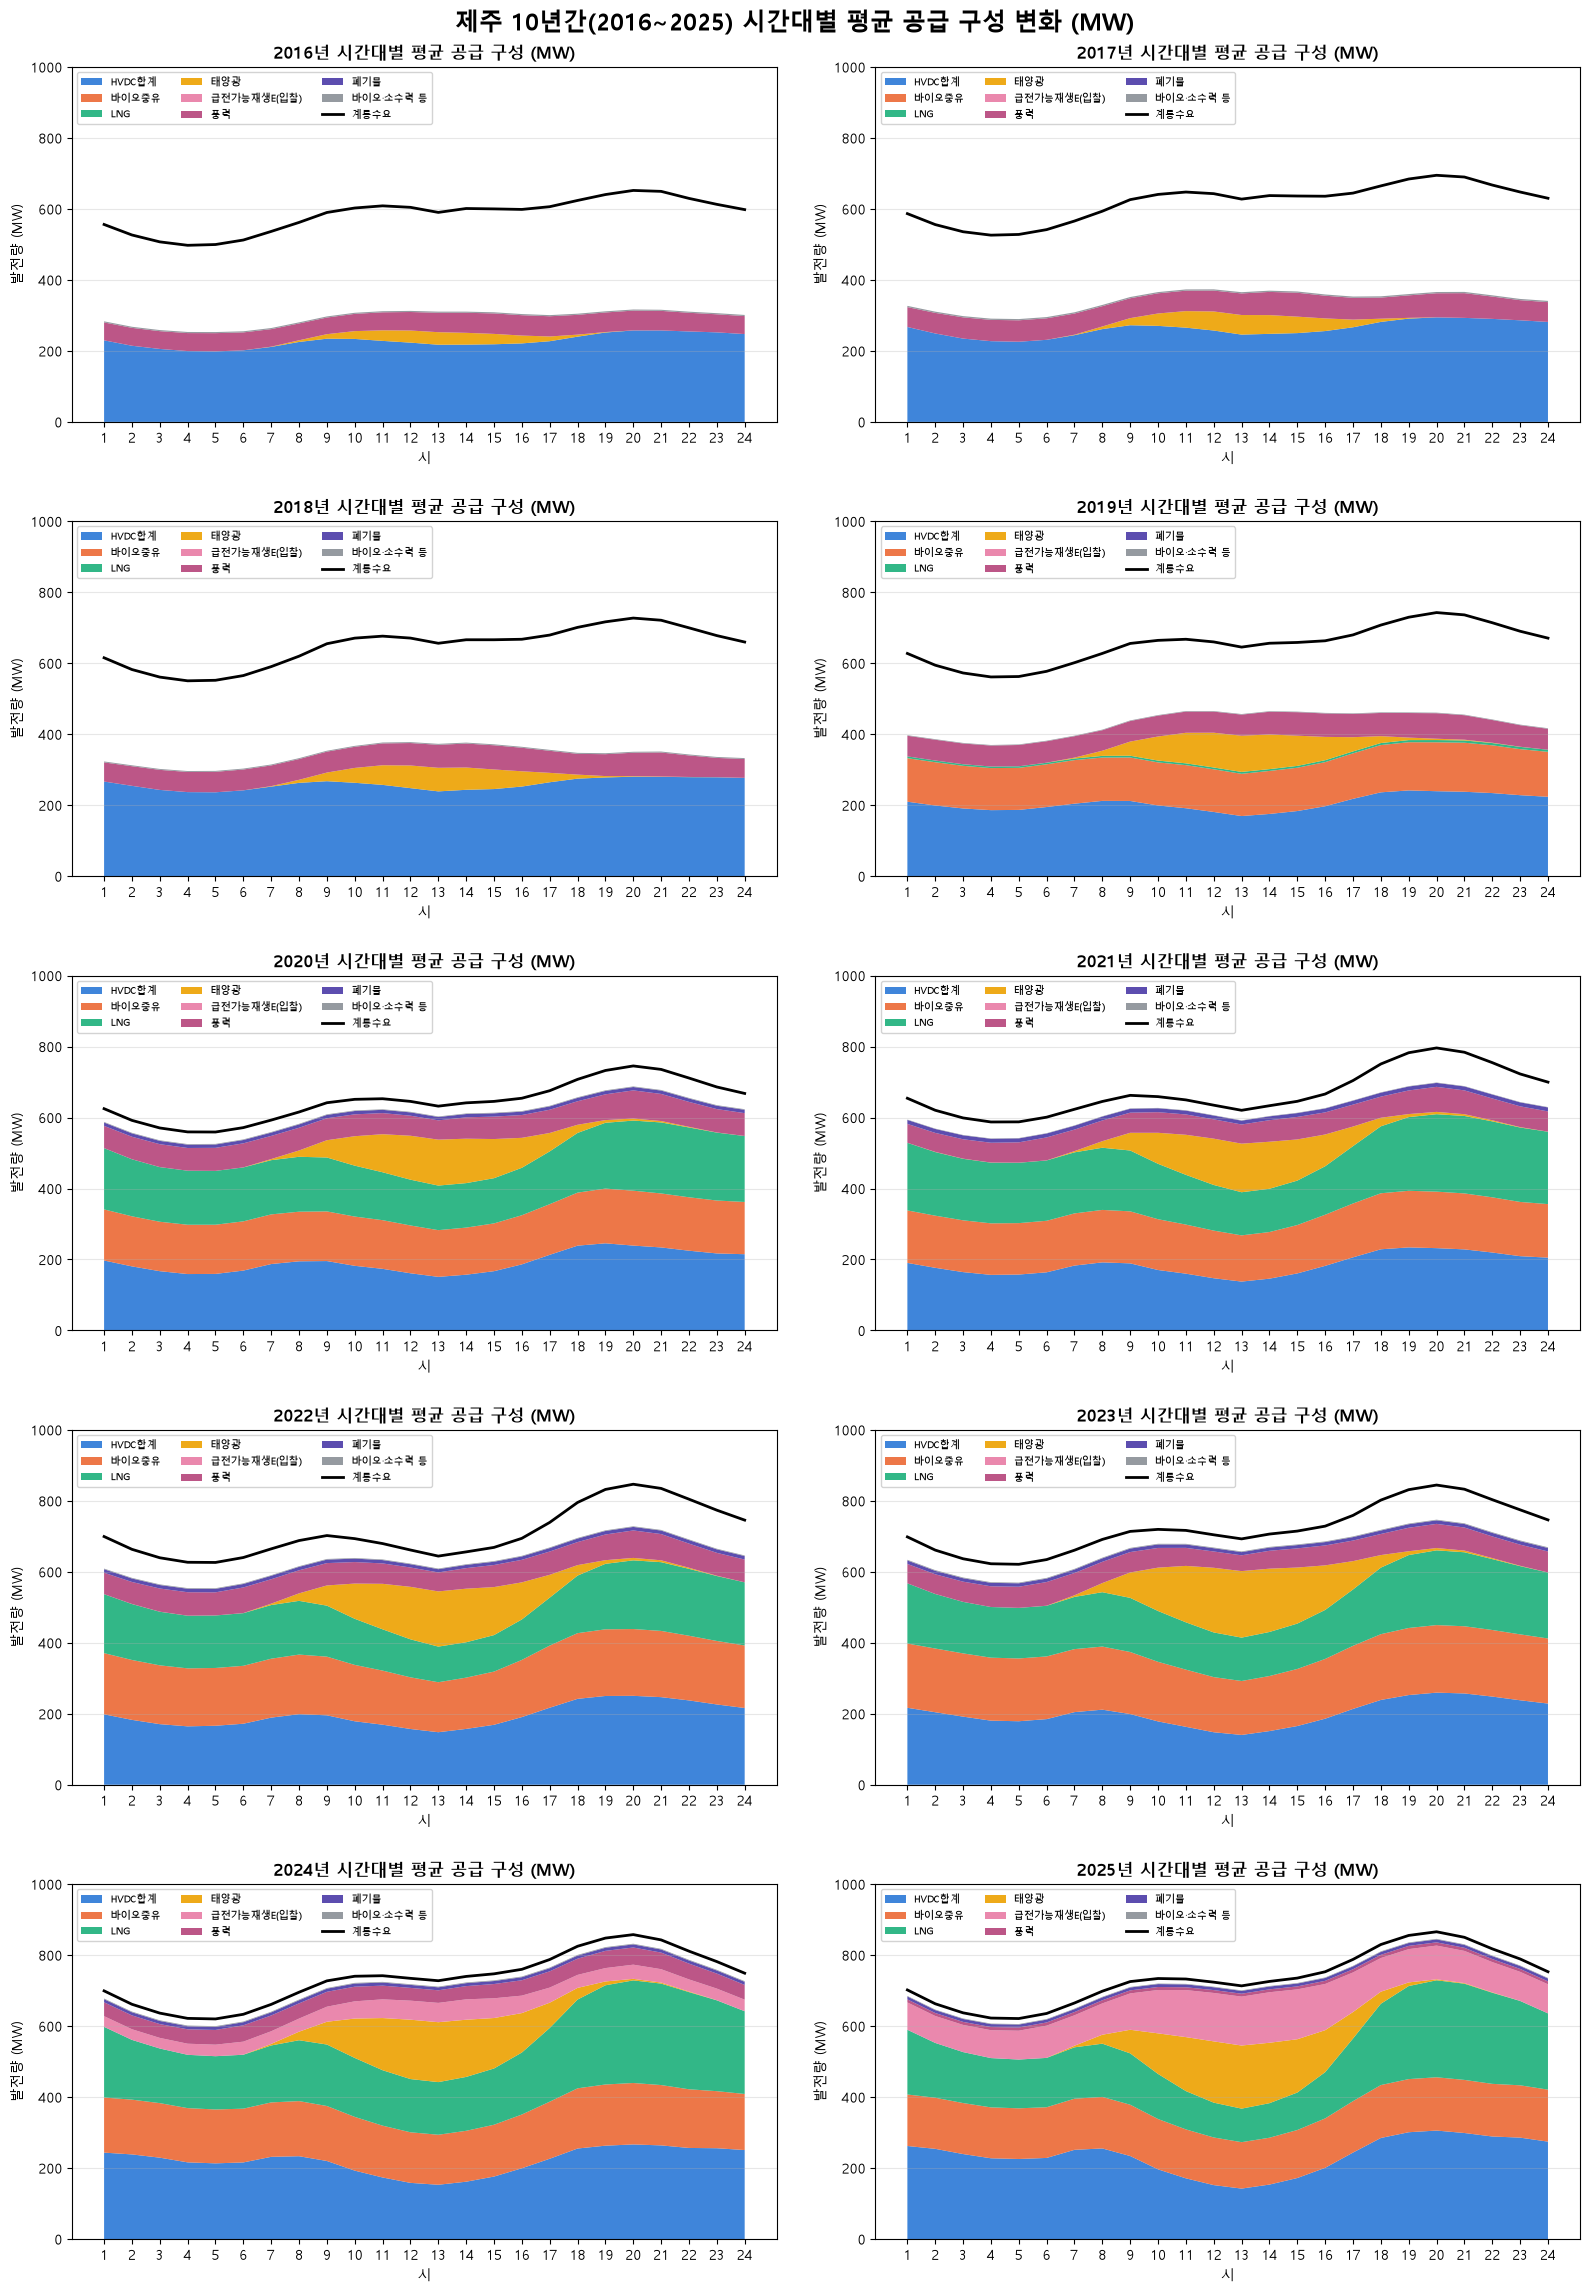

In [5]:
# 10년간(2016~2025) 시간대별 평균 공급 구성 변화 (5행 2열 서브플롯)
import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd
from pathlib import Path

# 한글 글꼴 설정 (Windows 기본: 맑은 고딕 우선 적용)
installed = {f.name for f in font_manager.fontManager.ttflist}
prefer = ['Malgun Gothic', 'NanumGothic', 'Noto Sans KR', 'Noto Sans CJK KR', 'Gulim']
font = next((n for n in prefer if n in installed), 'Malgun Gothic')
if font:
    plt.rcParams['font.family'] = font
plt.rcParams['axes.unicode_minus'] = False

# 엑셀 파일 로드 (시간대평균_MW 시트)
excel_path = '제주_시간별_전력수급_통합_2016-2025.xlsx' if Path('제주_시간별_전력수급_통합_2016-2025.xlsx').exists() else OUT / '제주_시간별_전력수급_통합_2016-2025.xlsx'
df_hourly = pd.read_excel(excel_path, sheet_name='시간대평균_MW')

# 첨부 이미지 기준 색상 및 8개 발전원 (누적 영역)
COLOR = {
    'HVDC합계': '#2a78d6',
    '바이오중유': '#eb6834',
    'LNG': '#1baf7a',
    '태양광': '#eda100',
    '급전가능재생E(입찰)': '#e87ba4',
    '풍력': '#b5447a',
    '폐기물': '#4a3aa7',
    '바이오·소수력 등': '#8a8f96'
}
stack = ['HVDC합계', '바이오중유', 'LNG', '태양광', '급전가능재생E(입찰)', '풍력', '폐기물', '바이오·소수력 등']

years = sorted(df_hourly['연'].unique())

# 5행 2열 그리드로 10개 연도 전체 비교
fig, axes = plt.subplots(5, 2, figsize=(16, 23))
fig.suptitle('제주 10년간(2016~2025) 시간대별 평균 공급 구성 변화 (MW)', fontsize=17, fontweight='bold', y=0.995)
axes = axes.flatten()

for i, y in enumerate(years):
    ax = axes[i]
    df_y = df_hourly[df_hourly['연'] == y].set_index('시(1~24)')
    
    # 8개 발전원 누적 영역 그래프
    ax.stackplot(df_y.index, [df_y[c] for c in stack], labels=stack, 
                 colors=[COLOR[c] for c in stack], alpha=0.9)
    # 9번째 항목: 계통수요 실선
    ax.plot(df_y.index, df_y['계통수요_MW'], color='black', lw=2, label='계통수요')
    
    ax.set_title(f'{y}년 시간대별 평균 공급 구성 (MW)', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 25))
    ax.set_xlabel('시', fontsize=10)
    ax.set_ylabel('발전량 (MW)', fontsize=10)
    ax.set_ylim(0, 1000)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(ncol=3, fontsize=7.5, loc='upper left', framealpha=0.85)

plt.tight_layout()
plt.subplots_adjust(top=0.97, hspace=0.28, wspace=0.14)
plt.show()

### 개별 연도 상세 조회 및 인터랙티브 위젯

원하는 연도(2016~2025)를 선택하여 첨부 이미지와 동일한 크기(`11 x 4.5`)로 확인하거나, 
2016~2019년 화석유류('중유·경유·등유')를 유류 항목에 통합하여 완전한 수급 일치 형태로 비교할 수 있습니다.

In [6]:
# 단일 연도 그래프 그리기 함수 (첨부 이미지 원본 비율: 11 x 4.5)
def plot_year_supply_profile(year=2025, include_legacy_oil=False):
    """
    year: 연도 (2016 ~ 2025)
    include_legacy_oil: True일 경우 2019년 이전 기존 유류(중유·경유·등유)를 바이오중유에 합산하여 표시
    """
    df_y = df_hourly[df_hourly['연'] == year].set_index('시(1~24)').copy()
    
    oil_col = '바이오중유'
    oil_label = '바이오중유'
    if include_legacy_oil:
        df_y['바이오중유(유류합계)'] = df_y['바이오중유'] + df_y['중유·경유·등유']
        oil_col = '바이오중유(유류합계)'
        oil_label = '유류(바이오+기존중유)'
    
    current_stack = ['HVDC합계', oil_col, 'LNG', '태양광', '급전가능재생E(입찰)', '풍력', '폐기물', '바이오·소수력 등']
    labels = ['HVDC합계', oil_label, 'LNG', '태양광', '급전가능재생E(입찰)', '풍력', '폐기물', '바이오·소수력 등']
    colors = [COLOR['HVDC합계'], COLOR['바이오중유'], COLOR['LNG'], COLOR['태양광'], 
              COLOR['급전가능재생E(입찰)'], COLOR['풍력'], COLOR['폐기물'], COLOR['바이오·소수력 등']]
    
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.stackplot(df_y.index, [df_y[c] for c in current_stack], labels=labels, colors=colors, alpha=0.9)
    ax.plot(df_y.index, df_y['계통수요_MW'], color='black', lw=2, label='계통수요')
    
    suffix = ' [유류 전체 포함]' if include_legacy_oil else ''
    ax.set_title(f'{year}년 시간대별 평균 공급 구성 (MW){suffix}', fontsize=12)
    ax.set_xticks(range(1, 25))
    ax.set_xlabel('시')
    ax.set_ylabel('발전량 (MW)')
    ax.legend(ncol=3, fontsize=9, loc='upper left', framealpha=0.85)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 인터랙티브 슬라이더 (Jupyter 실행 시 슬라이더로 연도 탐색)
try:
    from ipywidgets import interact, IntSlider, Checkbox
    interact(plot_year_supply_profile, 
             year=IntSlider(min=2016, max=2025, step=1, value=2025, description='연도:'),
             include_legacy_oil=Checkbox(value=False, description='기존 화석유류 포함'));
except ImportError:
    # 위젯이 없을 경우 기본 2025년 및 2016년 호출
    plot_year_supply_profile(2025)

interactive(children=(IntSlider(value=2025, description='연도:', max=2025, min=2016), Checkbox(value=False, desc…

### 10년간 시간대별 공급 구성의 주요 변화 분석 (요약)

1. **태양광 급증 및 덕커브(Duck Curve) 심화**:
   - 2016년 낮 13시 기준 태양광 평균 발전량은 약 **35.3 MW**에 불과했으나, 2025년에는 약 **177.8 MW**로 5배 이상 급증했습니다.
   - 이에 따라 낮 시간대(11~15시) 기저발전(HVDC 수전, 화력발전)의 출력이 크게 감발되는 '덕커브' 현상이 뚜렷해졌습니다.

2. **2024년 6월 제주 재생에너지 입찰제 도입**:
   - 2024년 중반부터 `급전가능재생E(입찰)` 제도가 시행되면서, 기존 '풍력'으로 분류되던 대다수 풍력 발전기가 급전가능 재생에너지 입찰 시장으로 편입되었습니다.
   - 2025년 그래프에서 분홍색(`급전가능재생E(입찰)`) 영역이 크게 나타나고 기존 자주색(`풍력`) 영역이 작아진 것은 입찰제 도입에 따른 시장 분류 변화를 반영합니다.

3. **화력 발전원의 친환경 전환**:
   - 2016~2018년 제주의 주요 화력 연료였던 '중유·경유·등유'는 2019~2020년을 거치며 청정 연료인 `LNG`와 탄소중립 연료인 `바이오중유`로 완전히 대체되었습니다.

4. **HVDC 연계선의 유연 운전**:
   - 2016년에는 낮 시간에도 HVDC를 통해 육지로부터 약 200 MW 이상 꾸준히 수전했으나, 2024~2025년에는 태양광 발전이 집중되는 낮 시간에 HVDC 수전량을 140 MW 수준까지 낮추거나 필요 시 역송하는 등 계통 안정성을 위한 유연 운전이 확대되었습니다.